# Задание

Используя модуль **datasets** библиотеки **sklearn**, загрузите базу вин (`.load_wine()`).

Используя шаблон ноутбука, выполните загрузку, подготовку и предобработку данных. Обязательное условие: разделение данных на три выборки осуществляется по шаблону (изменять параметры подготовки данных запрещается)!

Проведите серию экспериментов и добейтесь максимальной точности классификации на тестовой выборке выше 94%.

---

С помощью метода `.summary()` зафиксируйте количество параметров созданной вами нейронной сети.


#Шаблон ноутбука

In [1]:
# Последовательная модель НС
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization

# Утилиты для to_categorical()
from tensorflow.keras import utils

# Алгоритмы оптимизации для обучения модели
from tensorflow.keras.optimizers import Adam

# Библиотека для работы с массивами
import numpy as np

# Отрисовка графиков
import matplotlib.pyplot as plt

# Разделение данных на выборки
from sklearn.model_selection import train_test_split

# Для загрузки датасета
from sklearn.datasets import load_wine

# Отрисовка изображений в ноутбуке, а не в консоли или файле
%matplotlib inline

##Описание базы

1. Датасет состоит из набора данных о винах и их классах.
2. Данные по одному вину хранятся в numpy-массиве `x_data`: (`13` параметров).
3. В датасете `3` класса вин: `y_data`.
4. Количество примеров: `178`.

In [2]:
x_data = load_wine()['data']              # Загрузка набора данных о винах
y_data = load_wine()['target']            # Загрузка классов вин

print('Размерность x_data -', x_data.shape)
print('Размерность y_data -', y_data.shape)
print()

# Вывод примера данных
print('Данные по первому вину:',x_data[0])
print('Класс вина:',y_data[0])

Размерность x_data - (178, 13)
Размерность y_data - (178,)

Данные по первому вину: [1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
 2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
Класс вина: 0


##Подготовка данных

In [3]:
# Перевод в one hot encoding
y_data = utils.to_categorical(y_data, 3)

# Разбиение наборов на общую и тестовую выборки
x_all, x_test, y_all, y_test = train_test_split(x_data,
                                                y_data,
                                                test_size=0.1,
                                                shuffle=True,
                                                random_state = 6)

# Разбиение общей выборки на обучающую и проверочную
x_train, x_val, y_train, y_val = train_test_split(x_all,
                                                  y_all,
                                                  test_size=0.1,
                                                  shuffle=True,
                                                  random_state = 6)

print(x_train.shape)
print(y_train.shape)
print()
print(x_val.shape)
print(y_val.shape)

(144, 13)
(144, 3)

(16, 13)
(16, 3)


In [4]:
# ваше решение

# Построение и обучение модели

In [5]:
model = Sequential()

# Входной слой + скрытые слои
model.add(Dense(128, input_dim=x_train.shape[1], activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

# Выходной слой
model.add(Dense(3, activation='softmax'))

# Вывод архитектуры
model.summary()

c:\Users\melni\Desktop\ВУЗ\3курс\MathBasicforII\1 семестр\LR2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,603 (53.14 KB)

 Trainable params: 13,155 (51.39 KB)

 Non-trainable params: 448 (1.75 KB)

# Компиляция и обучение

In [6]:
# Компиляция модели
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Обучение модели
history = model.fit(
    x_train, y_train,
    epochs=150,
    batch_size=16,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.3611 - loss: 1.3485 - val_accuracy: 0.3750 - val_loss: 1.2874
Epoch 2/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4306 - loss: 1.1677 - val_accuracy: 0.6250 - val_loss: 1.4759
Epoch 3/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5417 - loss: 0.9589 - val_accuracy: 0.2500 - val_loss: 2.0402
Epoch 4/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5486 - loss: 1.0354 - val_accuracy: 0.2500 - val_loss: 2.4713
Epoch 5/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6250 - loss: 0.9117 - val_accuracy: 0.2500 - val_loss: 2.4742
Epoch 6/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5764 - loss: 0.8947 - val_accuracy: 0.2500 - val_loss: 2.3548
Epoch 7/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6319 - loss: 0.8279 - val_accuracy: 0.2500 - val_loss: 2.1720
Epoch 8/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6181 - loss: 0.7839 - val_accuracy: 0.2500 - val_loss: 1.92

# Графики обучения

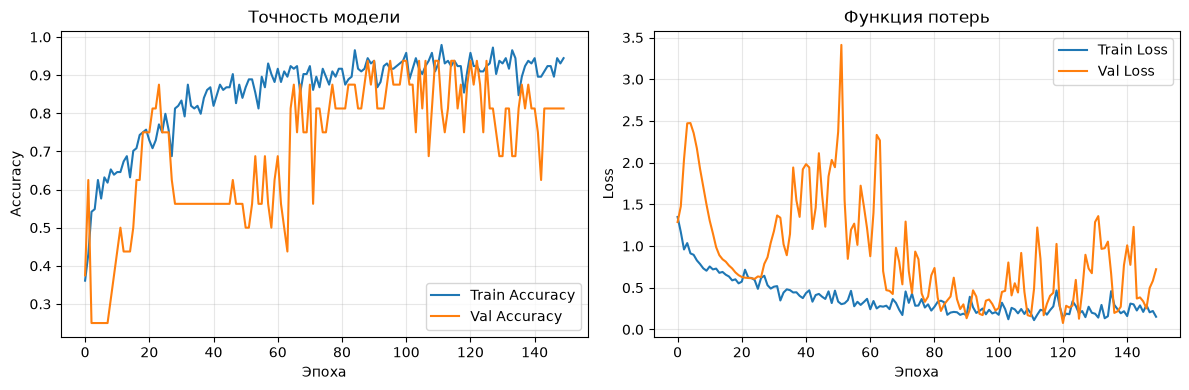

In [7]:
# График точности
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Точность модели')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# График потерь
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Функция потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Оценка модели

In [8]:
# Оценка на тестовой выборке
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("="*50)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*50)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Количество параметров: {model.count_params()}")
print("="*50)

if test_accuracy > 0.94:
    print("✅ Цель достигнута! Точность > 94%")
else:
    print("⚠️ Цель не достигнута. Требуется оптимизация.")

РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ
Test Loss:     0.3692
Test Accuracy: 0.9444 (94.44%)
Количество параметров: 13603
✅ Цель достигнута! Точность > 94%


# Матрица ошибок и детальный отчет

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


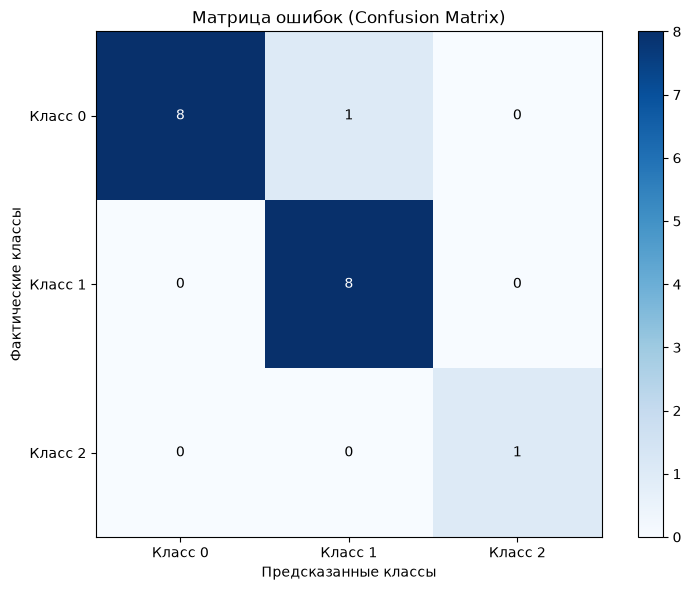


Отчет о классификации:
              precision    recall  f1-score   support

     Класс 0       1.00      0.89      0.94         9
     Класс 1       0.89      1.00      0.94         8
     Класс 2       1.00      1.00      1.00         1

    accuracy                           0.94        18
   macro avg       0.96      0.96      0.96        18
weighted avg       0.95      0.94      0.94        18



In [9]:
from sklearn.metrics import confusion_matrix, classification_report

# Предсказания
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Матрица ошибок
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.title('Матрица ошибок (Confusion Matrix)')
plt.xlabel('Предсказанные классы')
plt.ylabel('Фактические классы')
plt.xticks([0, 1, 2], ['Класс 0', 'Класс 1', 'Класс 2'])
plt.yticks([0, 1, 2], ['Класс 0', 'Класс 1', 'Класс 2'])

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j],
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

# Детальный отчет
print("\nОтчет о классификации:")
print(classification_report(y_true_classes, y_pred_classes,
                           target_names=['Класс 0', 'Класс 1', 'Класс 2']))

# Эксперименты с архитектурами
Эксперимент 1: Простая модель

In [10]:
model_simple = Sequential([
    Dense(32, input_dim=13, activation='relu'),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

model_simple.compile(optimizer=Adam(0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

history_simple = model_simple.fit(x_train, y_train,
                                  epochs=100, batch_size=16,
                                  validation_data=(x_val, y_val),
                                  verbose=0)

test_acc_simple = model_simple.evaluate(x_test, y_test, verbose=0)[1]
print(f"Простая модель: {test_acc_simple:.4f} ({test_acc_simple*100:.2f}%)")

c:\Users\melni\Desktop\ВУЗ\3курс\MathBasicforII\1 семестр\LR2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Простая модель: 0.9444 (94.44%)


Эксперимент 2: Модель с Dropout

In [11]:
model_dropout = Sequential([
    Dense(64, input_dim=13, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model_dropout.compile(optimizer=Adam(0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

history_dropout = model_dropout.fit(x_train, y_train,
                                   epochs=100, batch_size=16,
                                   validation_data=(x_val, y_val),
                                   verbose=0)

test_acc_dropout = model_dropout.evaluate(x_test, y_test, verbose=0)[1]
print(f"Модель с Dropout: {test_acc_dropout:.4f} ({test_acc_dropout*100:.2f}%)")

Модель с Dropout: 0.4444 (44.44%)


Эксперимент 3: Модель с BatchNormalization

In [12]:
model_bn = Sequential([
    Dense(64, input_dim=13, activation='relu'),
    BatchNormalization(),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

model_bn.compile(optimizer=Adam(0.001),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

history_bn = model_bn.fit(x_train, y_train,
                         epochs=100, batch_size=16,
                         validation_data=(x_val, y_val),
                         verbose=0)

test_acc_bn = model_bn.evaluate(x_test, y_test, verbose=0)[1]
print(f"Модель с BatchNorm: {test_acc_bn:.4f} ({test_acc_bn*100:.2f}%)")

Модель с BatchNorm: 1.0000 (100.00%)
